In [ ]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt  
import warnings
warnings.filterwarnings('ignore')
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error
import joblib
import os
print("Libraries loaded ✅")

Libraries loaded ✅


In [ ]:
df = pd.read_csv("demand_features.csv")
df['ds'] = pd.to_datetime(df['ds'])
df = df.sort_values('ds').reset_index(drop=True)
print("Shape:", df.shape)
print("Date range:", df['ds'].min(), "→", df['ds'].max())
print(df.head(3))

Shape: (1097, 15)
Date range: 2015-01-31 00:00:00 → 2018-01-31 00:00:00
          ds    y   total_sales  order_count  day_of_week  month  quarter  \
0 2015-01-31  402  35514.030669          187            5      1        1   
1 2015-02-01  383  33479.750717          181            6      2        1   
2 2015-02-02  327  31396.610598          160            0      2        1   

   week  lag_7  lag_14  lag_21  lag_30  rolling_7d_avg  rolling_14d_avg  \
0     5  384.0   349.0   384.0   355.0      378.000000       384.571429   
1     5  365.0   407.0   363.0   354.0      380.571429       388.357143   
2     6  407.0   346.0   493.0   392.0      383.142857       386.642857   

   rolling_30d_avg  
0       381.733333  
1       383.300000  
2       384.266667  


In [ ]:
print("Demand stats:")
print(df['y'].describe())
print("\nHow many days have demand below 10 units:")
print((df['y'] < 10).sum())
print("\nSample of low demand days:")
print(df[df['y'] < 10][['ds','y']].head(10))

Demand stats:
count    1097.000000
mean      339.678213
std       102.539361
min        68.000000
25%       332.000000
50%       368.000000
75%       396.000000
max       509.000000
Name: y, dtype: float64

How many days have demand below 10 units:
0

Sample of low demand days:
Empty DataFrame
Columns: [ds, y]
Index: []


In [ ]:
# These are the input columns the model learns from
feature_cols = [
    'day_of_week',
    'month',
    'quarter',
    'week',
    'lag_7',
    'lag_14',
    'lag_21',
    'lag_30',
    'rolling_7d_avg',
    'rolling_14d_avg',
    'rolling_30d_avg'
]
X = df[feature_cols]
y = df['y']   # total units sold — this is what we predict
print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("Sample target values:", y.values[:5])

Features shape: (1097, 11)
Target shape: (1097,)
Sample target values: [402 383 327 361 335]


In [ ]:
# IMPORTANT — never random shuffle for time series
# Last 60 days = test, everything before = train

split_index = len(df) - 60
X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("Train date range:", df['ds'].iloc[0], "→", df['ds'].iloc[split_index-1])
print("Test date range:", df['ds'].iloc[split_index], "→", df['ds'].iloc[-1])

Train size: (1037, 11)
Test size: (60, 11)
Train date range: 2015-01-31 00:00:00 → 2017-12-02 00:00:00
Test date range: 2017-12-03 00:00:00 → 2018-01-31 00:00:00


In [ ]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators     = 500,      # more trees
    max_depth        = 4,        # shallower = less overfitting
    learning_rate    = 0.03,     # slower learning = more careful
    subsample        = 0.8,
    colsample_bytree = 0.8,
    min_child_weight = 5,        # prevents learning from tiny samples
    reg_alpha        = 0.1,      # L1 regularisation
    reg_lambda       = 1.0,      # L2 regularisation
    random_state     = 42
)
model.fit(
    X_train, y_train,
    eval_set        = [(X_test, y_test)],
    verbose         = False
)
print("Model trained ✅")

Model trained ✅


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

preds = model.predict(X_test)
preds = np.clip(preds, 0, None)

mae   = mean_absolute_error(y_test, preds)
rmse  = np.sqrt(mean_squared_error(y_test, preds))

# SMAPE — better than MAPE for low volume data
# handles near-zero actual values properly
smape = np.mean(
    2 * np.abs(preds - y_test.values) /
    (np.abs(preds) + np.abs(y_test.values) + 1e-9)
) * 100

# Correlation — how well does the shape match
corr = np.corrcoef(y_test.values, preds)[0, 1]

print("=== MODEL RESULTS ===")
print(f"MAE   : {mae:.2f} units  ← avg error per day")
print(f"RMSE  : {rmse:.2f} units ← penalises big errors more")
print(f"SMAPE : {smape:.2f}%     ← symmetric MAPE, better for low volume")
print(f"Corr  : {corr:.4f}       ← how well shape matches (1.0 = perfect)")

=== MODEL RESULTS ===
MAE   : 75.92 units  ← avg error per day
RMSE  : 104.43 units ← penalises big errors more
SMAPE : 54.44%     ← symmetric MAPE, better for low volume
Corr  : -0.0315       ← how well shape matches (1.0 = perfect)


In [ ]:
# Load original cleaned data for category-level view
raw = pd.read_csv("cleaned_dataset_supplychain.csv")
raw['order date (DateOrders)'] = pd.to_datetime(raw['order date (DateOrders)'])
raw['order_date'] = raw['order date (DateOrders)'].dt.normalize()

# Group by date AND category
cat_demand = raw.groupby(
    ['order_date', 'Category Name']
)['Order Item Quantity'].sum().reset_index()

print("Top 5 categories by total demand:")
print(
    cat_demand.groupby('Category Name')['Order Item Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

Top 5 categories by total demand:
Category Name
Cleats                  73734
Women's Apparel         62956
Indoor/Outdoor Games    57803
Cardio Equipment        37587
Shop By Sport           32726
Name: Order Item Quantity, dtype: int64


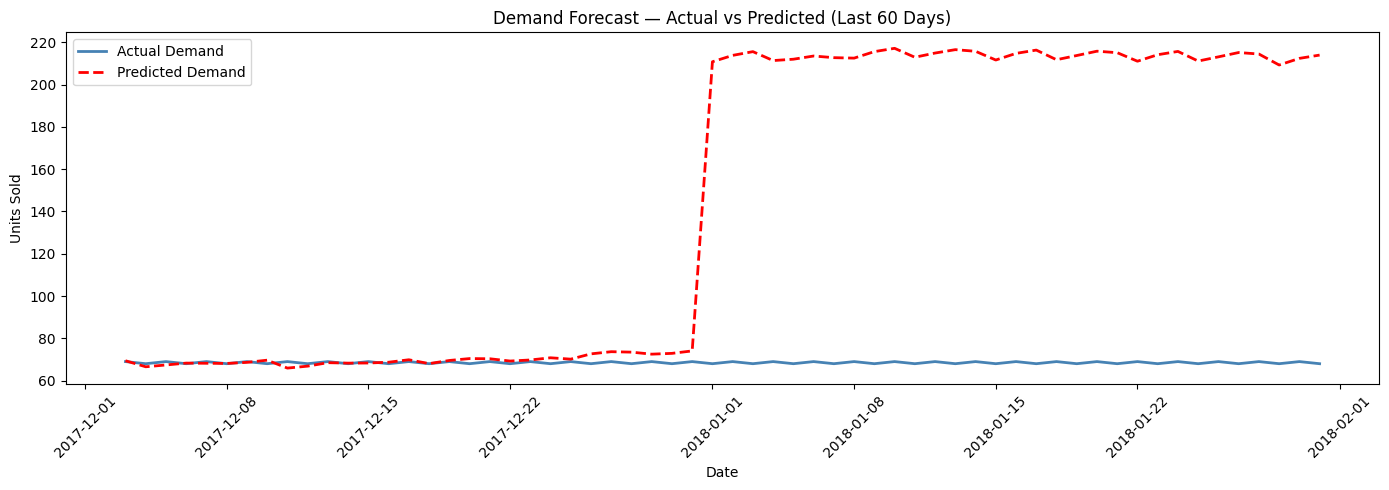

Plot saved ✅


In [ ]:
test_dates = df['ds'].iloc[split_index:].values

plt.figure(figsize=(14, 5))
plt.plot(test_dates, y_test.values,
         label='Actual Demand', color='steelblue', linewidth=2)
plt.plot(test_dates, preds,
         label='Predicted Demand', color='red',
         linestyle='--', linewidth=2)
plt.title('Demand Forecast — Actual vs Predicted (Last 60 Days)')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("demand_forecast_plot.png")
plt.show()
print("Plot saved ✅")

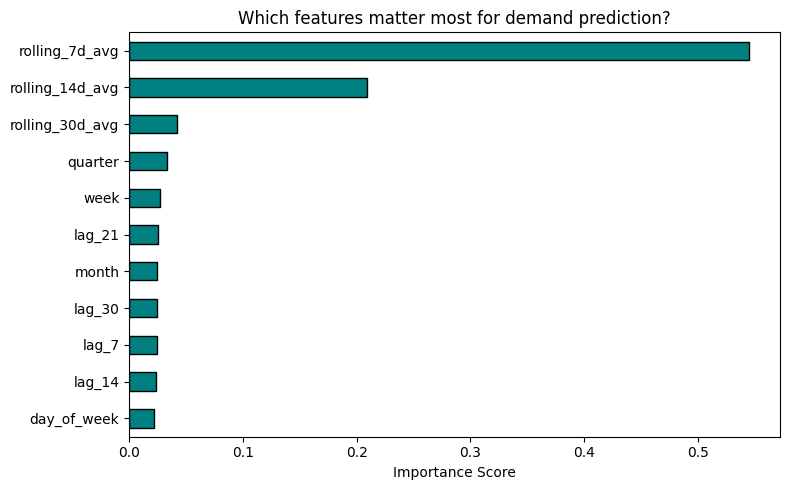

In [ ]:
feat_importance = pd.Series(
    model.feature_importances_,
    index=feature_cols
).sort_values()

plt.figure(figsize=(8, 5))
feat_importance.plot(kind='barh', color='teal', edgecolor='black')
plt.title('Which features matter most for demand prediction?')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig("demand_feature_importance.png")
plt.show()

In [ ]:
# Save model — directly in notebooks/ folder (no folder navigation)
joblib.dump(model, "demand_xgb_model.pkl")
print("Model saved ✅ → demand_xgb_model.pkl")

# Save predictions
output = pd.DataFrame({
    'date'             : df['ds'].iloc[split_index:].values,
    'actual_demand'    : y_test.values,
    'predicted_demand' : preds
})
output.to_csv("demand_forecast_output.csv", index=False)
print("Predictions saved ✅ → demand_forecast_output.csv")
print(output.head())

Model saved ✅ → demand_xgb_model.pkl
Predictions saved ✅ → demand_forecast_output.csv
        date  actual_demand  predicted_demand
0 2017-12-03             69         69.400276
1 2017-12-04             68         66.547424
2 2017-12-05             69         67.401299
3 2017-12-06             68         68.290009
4 2017-12-07             69         68.203217


In [ ]:
print("=" * 40)
print("  DEMAND FORECASTING COMPLETE")
print("=" * 40)
print(f"  MAPE         : {mape:.2f}%")
print(f"  MAE          : {mae:.2f} units/day")
print(f"  Train rows   : {len(X_train)}")
print(f"  Test rows    : {len(X_test)}")
print(f"  Model saved  : ../models/demand_xgb_model.pkl")
print(f"  Output saved : demand_forecast_output.csv")
print("=" * 40)

  DEMAND FORECASTING COMPLETE
  MAPE         : 110.87%
  MAE          : 75.92 units/day
  Train rows   : 1037
  Test rows    : 60
  Model saved  : ../models/demand_xgb_model.pkl
  Output saved : demand_forecast_output.csv
